Hu moments của apple:
[ 7.60697259e-04  6.73822542e-08  8.82633858e-11  2.70414505e-11
  1.30498499e-21  6.94345636e-15 -2.05708426e-22]

Hu moments của grapes:
[9.31358153e-04 1.13515922e-07 4.40422439e-10 4.01034002e-11
 5.12549767e-21 1.35005606e-14 1.46132339e-21]

Hu moments (log-scale) của apple:
[  3.11878815   7.17145446  10.05421942  10.56797002  20.88439448
  14.15842429 -21.68674792]

Hu moments (log-scale) của grapes:
[ 3.03088328  6.94494322  9.35613056 10.3968188  20.29026396 13.8696482
 20.83525366]


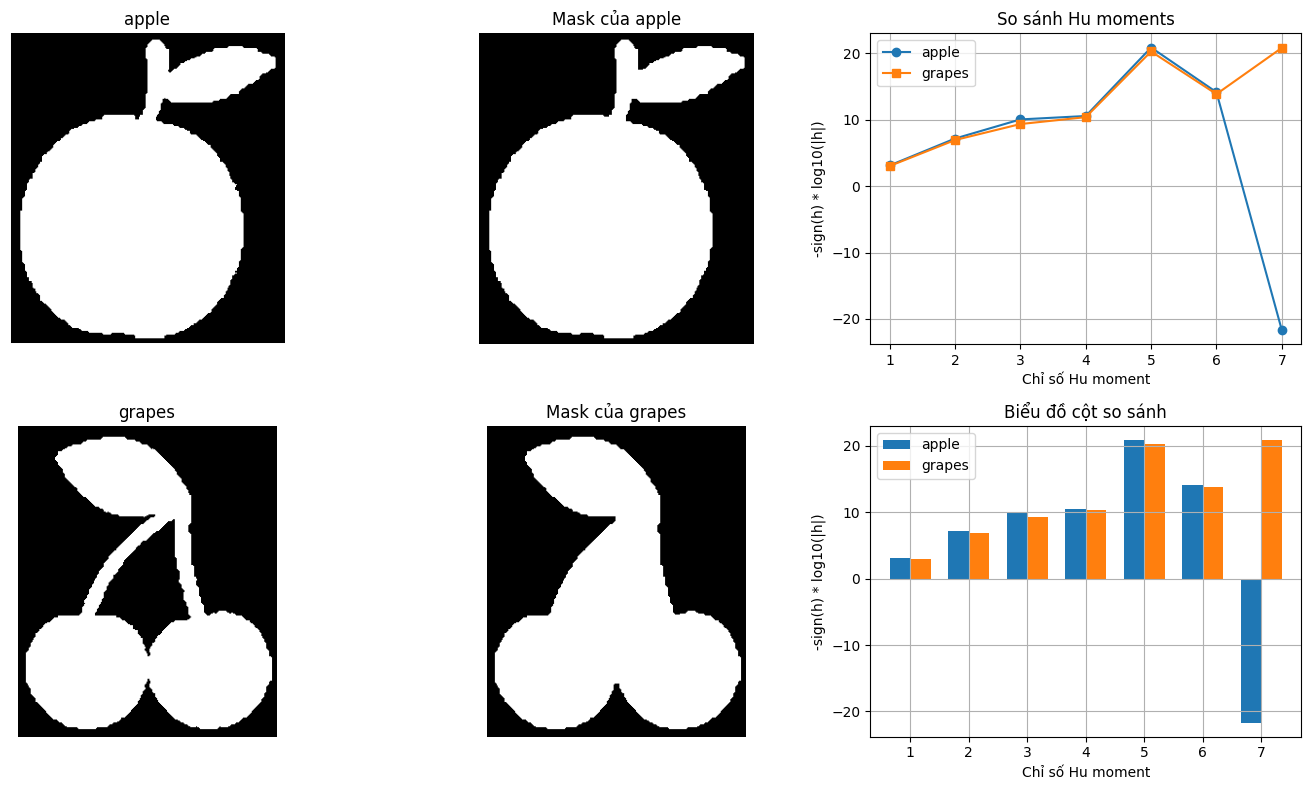


Kiểm tra kết quả:
- Đọc ảnh thành công.
- Tạo mask thành công.
- Tính đủ 7 Hu moments cho mỗi đối tượng.
- Các giá trị log-scale hợp lệ.


In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: SO SÁNH HÌNH DẠNG BẰNG HU MOMENTS
# Chương/Mục liên quan: Chương 5 - Đặc trưng hình dạng
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa cách biểu diễn hình dạng đối tượng bằng 7 Hu moments.
# - Giúp người học quan sát sự khác biệt hình dạng giữa hai đối tượng.
# - Liên hệ giữa mask nhị phân, moment hình học và đặc trưng bất biến Hu.

# Sau khi chạy code, người học cần:
# 1. Hiểu được cách tách mask đối tượng chính khỏi nền.
# 2. Hiểu được cách tính 7 Hu moments từ mask nhị phân.
# 3. Quan sát được sự khác biệt giữa hai đối tượng qua đồ thị Hu moments.

# Input:
# - Dữ liệu đầu vào: hai ảnh nhị phân từ GitHub.
# - Kiểu dữ liệu: ảnh màu, sau đó chuyển sang ảnh xám và mask nhị phân.

# Output:
# - Ảnh gốc.
# - Mask của từng đối tượng.
# - Giá trị Hu moments.
# - Đồ thị so sánh Hu moments ở thang log.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

# URL ảnh
apple_url = "https://github.com/lthavnu/cv-book/raw/main/images/apple_binary.png"
grapes_url = "https://github.com/lthavnu/cv-book/raw/main/images/grapes_binary.png"

# Đọc ảnh từ URL
def read_gitlab_image(url):
    resp = urlopen(url)
    img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_COLOR)

# Đọc ảnh
I_apple = read_gitlab_image(apple_url)
I_grapes = read_gitlab_image(grapes_url)

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

# Việc hiển thị ảnh đầu vào được tích hợp trong hàm show_results ở phần sau.

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Tách đối tượng chính khỏi nền
def extract_main_mask(I_bgr):
    # Chuyển sang ảnh xám
    I_gray = cv2.cvtColor(I_bgr, cv2.COLOR_BGR2GRAY)

    # Nhị phân hóa bằng Otsu
    _, mask = cv2.threshold(
        I_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Nếu vùng trắng chiếm quá nhiều thì đảo mask
    # if np.sum(mask == 255) > mask.size // 2:
    #     mask = cv2.bitwise_not(mask)

    # Làm sạch mask bằng phép mở và phép đóng hình thái học
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # Giữ lại thành phần liên thông lớn nhất
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    clean_mask = np.zeros_like(mask)

    if len(contours) > 0:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(clean_mask, [largest_contour], -1, 255, thickness=-1)

    return I_gray, clean_mask

# Tính 7 Hu moments
def compute_hu_moments(mask):
    # Dòng này tương ứng với bước tính moment hình học từ mask nhị phân
    M = cv2.moments(mask)

    # Dòng này tương ứng với bước tính 7 Hu moments từ các moment chuẩn hóa
    hu = cv2.HuMoments(M).flatten()

    return hu

# Log-transform Hu moments để dễ quan sát
def log_transform_hu(hu):
    eps = 1e-30

    # Dòng này đưa Hu moments về thang log để dễ so sánh trực quan
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + eps)

    return hu_log

# Tách đối tượng
I_apple_gray, mask_apple = extract_main_mask(I_apple)
I_grapes_gray, mask_grapes = extract_main_mask(I_grapes)

# Tính Hu moments
hu_apple = compute_hu_moments(mask_apple)
hu_grapes = compute_hu_moments(mask_grapes)

# Đổi sang log-scale để dễ so sánh
hu_apple_log = log_transform_hu(hu_apple)
hu_grapes_log = log_transform_hu(hu_grapes)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

# Hiển thị kết quả
def show_results(I1_bgr, mask1, hu1_log, name1,
                 I2_bgr, mask2, hu2_log, name2):
    I1_rgb = cv2.cvtColor(I1_bgr, cv2.COLOR_BGR2RGB)
    I2_rgb = cv2.cvtColor(I2_bgr, cv2.COLOR_BGR2RGB)

    x = np.arange(1, 8)

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(I1_rgb)
    plt.title(name1)
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(mask1, cmap="gray")
    plt.title(f"Mask của {name1}")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.plot(x, hu1_log, marker="o", label=name1)
    plt.plot(x, hu2_log, marker="s", label=name2)
    plt.xticks(x)
    plt.xlabel("Chỉ số Hu moment")
    plt.ylabel("-sign(h) * log10(|h|)")
    plt.title("So sánh Hu moments")
    plt.legend()
    plt.grid(True)

    plt.subplot(2, 3, 4)
    plt.imshow(I2_rgb)
    plt.title(name2)
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(mask2, cmap="gray")
    plt.title(f"Mask của {name2}")
    plt.axis("off")

    plt.subplot(2, 3, 6)
    width = 0.35
    plt.bar(x - width / 2, hu1_log, width=width, label=name1)
    plt.bar(x + width / 2, hu2_log, width=width, label=name2)
    plt.xticks(x)
    plt.xlabel("Chỉ số Hu moment")
    plt.ylabel("-sign(h) * log10(|h|)")
    plt.title("Biểu đồ cột so sánh")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# In ra giá trị Hu moments
print("Hu moments của apple:")
print(hu_apple)

print("\nHu moments của grapes:")
print(hu_grapes)

print("\nHu moments (log-scale) của apple:")
print(hu_apple_log)

print("\nHu moments (log-scale) của grapes:")
print(hu_grapes_log)

# Hiển thị ảnh, mask và đồ thị so sánh
show_results(
    I_apple, mask_apple, hu_apple_log, "apple",
    I_grapes, mask_grapes, hu_grapes_log, "grapes"
)

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

# Kiểm tra ảnh có được đọc thành công hay không
assert I_apple is not None, "Không đọc được ảnh apple."
assert I_grapes is not None, "Không đọc được ảnh grapes."

# Kiểm tra mask có cùng kích thước với ảnh xám tương ứng hay không
assert mask_apple.shape == I_apple_gray.shape, "Mask apple không đúng kích thước."
assert mask_grapes.shape == I_grapes_gray.shape, "Mask grapes không đúng kích thước."

# Kiểm tra số lượng Hu moments
assert len(hu_apple) == 7, "Hu moments của apple không đủ 7 giá trị."
assert len(hu_grapes) == 7, "Hu moments của grapes không đủ 7 giá trị."

# Kiểm tra giá trị Hu moments sau log-transform có hợp lệ hay không
assert np.all(np.isfinite(hu_apple_log)), "Hu moments log-scale của apple có giá trị không hợp lệ."
assert np.all(np.isfinite(hu_grapes_log)), "Hu moments log-scale của grapes có giá trị không hợp lệ."

print("\nKiểm tra kết quả:")
print("- Đọc ảnh thành công.")
print("- Tạo mask thành công.")
print("- Tính đủ 7 Hu moments cho mỗi đối tượng.")
print("- Các giá trị log-scale hợp lệ.")

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Gợi ý 1:
# Thay đổi kích thước kernel trong phép morphology, ví dụ từ (5, 5) sang (3, 3) hoặc (7, 7),
# để quan sát ảnh hưởng của bước làm sạch mask.

# Gợi ý 2:
# Bật lại đoạn đảo mask nếu vùng trắng chiếm quá nhiều,
# để kiểm tra ảnh hưởng của việc chọn foreground và background.

# Gợi ý 3:
# Thay URL ảnh đầu vào bằng các ảnh nhị phân khác,
# rồi quan sát sự thay đổi của 7 Hu moments.